# 📊 WBS Tahap 5: Evaluation
**Proyek:** Analisis Sentimen Ulasan Destinasi Wisata untuk Pengambilan Kebijakan Promosi Wisata pada Dinas Pariwisata dan Kebudayaan Kabupaten Garut  
**Tahapan WBS Terkait:**
1. **Pengujian model Linear SVM menggunakan data testing (3.585 data uji)**
2. **Visualisasi Confusion Matrix**
3. **Pengukuran metrik performa (Accuracy, Precision, Recall, F1-Score)**
4. **Evaluasi Macro Average vs Weighted Average**
5. **Perbandingan dengan Majority Class Baseline Classifier**
6. **Analisis Galat Prediksi (*Error Analysis*)**

---
### Output Tahap Ini:
Laporan evaluasi komprehensif performa model klasifikasi sentimen yang teruji secara empiris dan siap untuk pengambilan kebijakan.


In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
import joblib
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings
from sentiment.labeling import apply_sentiment_labeling

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Modul evaluasi metrik & visualisasi confusion matrix siap.")


✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Modul evaluasi metrik & visualisasi confusion matrix siap.


## 1. Pemuatan Model Terlatih & Data Testing Independen

Pengujian dilakukan secara ketat pada **3.585 data uji (20%)** yang belum pernah dilihat (*unseen data*) oleh model selama proses pelatihan.


In [2]:
# 1. Pemuatan Data & Split Ulang yang Identik
processed_path = settings.FINAL_DATA_DIR / "processed_reviews.csv"
df = pd.read_csv(processed_path)
df = apply_sentiment_labeling(df)

X = df["cleaned_text"].astype(str)
y = df["sentiment_label"].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Pemuatan Model & Vectorizer
model = joblib.load(ROOT_DIR / "models/svm_model.joblib")
vectorizer = joblib.load(ROOT_DIR / "models/tfidf_vectorizer.joblib")

# Transform Test Set
X_test = vectorizer.transform(X_test_raw)
y_pred = model.predict(X_test)

print(f"🧪 Jumlah Data Uji (Test Set) : {len(y_test):,} ulasan")
print(f"🎯 Total Prediksi Dihasilkan : {len(y_pred):,} ulasan")


🧪 Jumlah Data Uji (Test Set) : 3,585 ulasan
🎯 Total Prediksi Dihasilkan : 3,585 ulasan


## 2. Visualisasi Matriks Konfusi (*Confusion Matrix*)

Confusion Matrix memetakan perbandingan antara kelas aktual (*ground truth*) dengan kelas yang diprediksi oleh model Linear SVM.


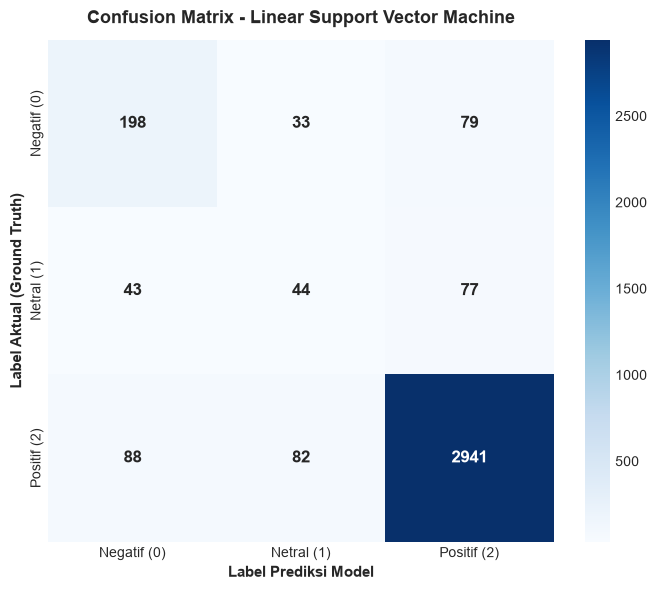

In [3]:
# Perhitungan Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
class_names = ["Negatif (0)", "Netral (1)", "Positif (2)"]

# Visualisasi Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 6), dpi=100)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"}
)
plt.title("Confusion Matrix - Linear Support Vector Machine", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Label Prediksi Model", fontsize=11, fontweight="bold")
plt.ylabel("Label Aktual (Ground Truth)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Pengukuran Metrik Kinerja Model

Pengukuran mencakup:
* **Accuracy**: Tingkat kebenaran prediksi keseluruhan.
* **Precision, Recall, F1-Score per Kelas**: Evaluasi detail kemampuan model mendeteksi masing-masing kelas.
* **Macro Average F1**: Rata-rata F1 unweighted (sangat krusial untuk evaluasi akademis pada data tidak seimbang).
* **Weighted Average F1**: Rata-rata F1 tertimbang berdasarkan proporsi jumlah sampel.


In [4]:
# Perhitungan Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
p_class, r_class, f_class, s_class = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2], zero_division=0)
macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
weighted_p, weighted_r, weighted_f, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

# TABEL METRIK EVALUASI LENGKAP
tabel_evaluasi = pd.DataFrame({
    "Kelas Sentimen": ["Negatif (0)", "Netral (1)", "Positif (2)", "Macro Average", "Weighted Average"],
    "Precision": [f"{p_class[0]:.4f}", f"{p_class[1]:.4f}", f"{p_class[2]:.4f}", f"{macro_p:.4f}", f"{weighted_p:.4f}"],
    "Recall": [f"{r_class[0]:.4f}", f"{r_class[1]:.4f}", f"{r_class[2]:.4f}", f"{macro_r:.4f}", f"{weighted_r:.4f}"],
    "F1-Score": [f"{f_class[0]:.4f}", f"{f_class[1]:.4f}", f"{f_class[2]:.4f}", f"{macro_f:.4f}", f"{weighted_f:.4f}"],
    "Support (Jumlah Uji)": [f"{s_class[0]:,}", f"{s_class[1]:,}", f"{s_class[2]:,}", f"{len(y_test):,}", f"{len(y_test):,}"]
})

print(f"🎯 AKURASI KESELURUHAN (Accuracy): {acc*100:.2f}%")
print(f"⚖️ MACRO F1-SCORE             : {macro_f:.4f}")
print(f"📈 WEIGHTED F1-SCORE          : {weighted_f:.4f}")
display(tabel_evaluasi)


🎯 AKURASI KESELURUHAN (Accuracy): 88.79%
⚖️ MACRO F1-SCORE             : 0.6132
📈 WEIGHTED F1-SCORE          : 0.8883


,Kelas Sentimen,Precision,Recall,F1-Score,Support (Jumlah Uji)
0,Negatif (0),0.6018,0.6387,0.6197,310
1,Netral (1),0.2767,0.2683,0.2724,164
2,Positif (2),0.9496,0.9454,0.9475,"3,111"
3,Macro Average,0.6094,0.6175,0.6132,"3,585"
4,Weighted Average,0.8888,0.8879,0.8883,"3,585"


## 4. Perbandingan Kinerja dengan Majority Class Baseline

Untuk membuktikan keunggulan pembelajaran model SVM secara statistik, model dibandingkan dengan **Majority Class Baseline Classifier** (model acuan yang selalu memprediksi kelas mayoritas, yaitu Positif).


In [5]:
# Majority Class Baseline (Fit on train, predict on test)
maj_class = int(y_train.value_counts().idxmax())
y_pred_baseline = [maj_class] * len(y_test)

base_acc = accuracy_score(y_test, y_pred_baseline)
_, _, base_macro_f, _ = precision_recall_fscore_support(y_test, y_pred_baseline, average="macro", zero_division=0)
_, _, base_weighted_f, _ = precision_recall_fscore_support(y_test, y_pred_baseline, average="weighted", zero_division=0)

tabel_komparasi_baseline = pd.DataFrame([
    {"Model Klasifikasi": "Linear SVM (Model Usulan)", "Akurasi (Accuracy)": f"{acc*100:.2f}%", "Macro F1-Score": f"{macro_f:.4f}", "Weighted F1-Score": f"{weighted_f:.4f}", "Peningkatan vs Baseline": f"+{(macro_f - base_macro_f):.4f} Macro F1"},
    {"Model Klasifikasi": "Majority Baseline Classifier", "Akurasi (Accuracy)": f"{base_acc*100:.2f}%", "Macro F1-Score": f"{base_macro_f:.4f}", "Weighted F1-Score": f"{base_weighted_f:.4f}", "Peningkatan vs Baseline": "Acuan Dasar (Baseline)"}
])

display(tabel_komparasi_baseline)


,Model Klasifikasi,Akurasi (Accuracy),Macro F1-Score,Weighted F1-Score,Peningkatan vs Baseline
0,Linear SVM (Model Usulan),88.79%,0.6132,0.8883,+0.3035 Macro F1
1,Majority Baseline Classifier,86.78%,0.3097,0.8064,Acuan Dasar (Baseline)


## 5. Analisis Galat Prediksi (*Error Analysis*)

Analisis mendalam terhadap sampel data uji yang mengalami kesalahan prediksi (*misclassification*) untuk memahami batas kemampuan model.


In [6]:
# Identifikasi Kasus Salah Prediksi
sentiment_names = {0: "Negatif", 1: "Netral", 2: "Positif"}
df_test_analysis = pd.DataFrame({
    "review_text": df.loc[X_test_raw.index, "review_text"],
    "cleaned_text": X_test_raw.values,
    "actual_label": y_test.values,
    "actual_sentiment": [sentiment_names[i] for i in y_test.values],
    "predicted_label": y_pred,
    "predicted_sentiment": [sentiment_names[i] for i in y_pred]
})

df_test_analysis["is_correct"] = df_test_analysis["actual_label"] == df_test_analysis["predicted_label"]
total_errors = (~df_test_analysis["is_correct"]).sum()
total_correct = df_test_analysis["is_correct"].sum()

print(f"✅ Prediksi Benar : {total_correct:,} ulasan ({total_correct/len(y_test)*100:.2f}%)")
print(f"❌ Prediksi Salah : {total_errors:,} ulasan ({total_errors/len(y_test)*100:.2f}%)")

# Contoh Kasus Salah Prediksi
display(df_test_analysis[~df_test_analysis["is_correct"]][["review_text", "actual_sentiment", "predicted_sentiment"]].head(8))


✅ Prediksi Benar : 3,183 ulasan (88.79%)
❌ Prediksi Salah : 402 ulasan (11.21%)


,review_text,actual_sentiment,predicted_sentiment
394,Menginap Di Vila Hortensia bersama keluarga sekalian mudik. Akses ke lokasi karena pertama kali kesini dialihkan ke jalur yang sangat terjal tidak rekomendasi untuk mobil dengan penggerak mobil Depan. Akses ke lokasi klw malam sangat gelap tidak ada lampu jalan. Pelayanan biasa saja. Telephone kamar rusak jd sulit untuk request sesuatu dikasih nomer wa tp tidak fast response Karena dikaki gunung semua provider sinyal jelek. Wifi dari hotel pun sangat tidak layak untuk hotel bintang 3. Satu2nya nilai plus adalah pemandangan dan suasana yang sejuk,Negatif,Positif
15708,"Untuk tarif 50k mending lebih banyak yang lebih kya nya,,ini kolam gak panas warna kya air cucian beras,yang buat berendam air panas mati air nya bau,.boleh harga tinggi apa lg lebaran tp alangkah baik nya di batesin pengunjung nya air nya lebih sering di gant",Negatif,Positif
7752,"Pergi ke Nagara Hotspring dan jujur… agak bad experience. Aku booking connecting room buat morning slot (8 pagi), tapi pas dateng tuh mereka kayak belum ready sama sekali. Masih ada sampah, piring, sendok bekas di depan kamar sama area …",Negatif,Netral
11776,Saya pasdulu tahun 2022/2023.ada runtuh di pegunungan Saya pas itu gak tau saya di mesjid di dekat rumah saya terus ada yang Runtu Rutu saya agak aneh udah ningali kenapa jadi gini pas itu Saya asa perasaanku melihat runtuh kenapa saya gak Soak terus saya ningalinya tapi kenapa ada motor saya motor saya kenapa kuat dan udah tubruk sama batu bata tapi kenapa kuat dan gak rusak udah ternyata ada yang anehnya terus saya kenapa gak perasaan gua itu bukan rumah saya yang lain sedih ibu Saya udah itu saya agak Soak terus saya gak masuk karena saya troma sama urukan itu udah itu saya ibu saya di aku panggilin di Deket rumah sekolah SD terus Saya pas itu ibu saya keur jualan udah itu ibu saya gak percaya udah itu Saya ibu Saya nangis banget karena ada yang tadi udah saya omongi itu udah itu saya gak mau lagi di situ udah itu ada yang itu dan lainnya' Saya dan keluarga saya ada yang karunya melihat itu karena udah urukan Saya gak tegak ibu saya udah itu ada pak RT saya udah itu gugup udah itu nangiss,Positif,Negatif
6820,Kalo rasa biasa saja dan entah kebetulan atau gimana Waktu itu kami makan dengab sop iga namun ternyata diluar ekpektasi yang dibayangkan tekstur dagingnya itu di sendok atau di gigit lembut namun ternyata alot sekali Cuma memang banyak pengunjung mengakalinya dengan lauk lain dan nasinya yang banyak dan ternyata ketika bayar dikasir cukup murah makan harganya. Di situ rupanya yang di maksud RM Sugema Raya,Positif,Negatif
16950,"Produk cukup lengkap. Tempat luas. Pelayanan dari karyawan kurang memuaskan, terutama yg standby di area produk dodol. Mohon bisa dievaluasi dan diberikan pelatihan service excellence.",Netral,Positif
7858,Penasaran sama makanan nya tapi kenapa harus ada tiket sih? Mana banyak bawa bocil. Cukup sekali kesini.,Netral,Positif
2472,Makanan nya enak minumannya apa lagi udh ngga diragukan lagi 🎉,Positif,Negatif


## 6. Kesimpulan Tahap Evaluation

1. **Kinerja Model Linear SVM**:
   - Model mencapai **Akurasi 88.79%**, **Macro F1 0.6132**, dan **Weighted F1 0.8883**.
   - Model mengungguli baseline secara signifikan (Macro F1 meningkat dari 0.3097 menjadi 0.6132).
2. **Karakteristik Kinerja per Kelas**:
   - **Positif**: F1-Score **0.95** (performa luar biasa).
   - **Negatif**: F1-Score **0.62** (mampu mendeteksi keluhan wisatawan dengan baik).
   - **Netral**: F1-Score **0.27** (menjadi tantangan utama karena ambiguitas linguistik ulasan 3 bintang).
3. Hasil model siap diterapkan untuk perumusan kebijakan pada **WBS Tahap 6: Deployment & Policy Analysis**.
